In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import time

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                120        1
   valid     1000                120        1
    test      500                120        1



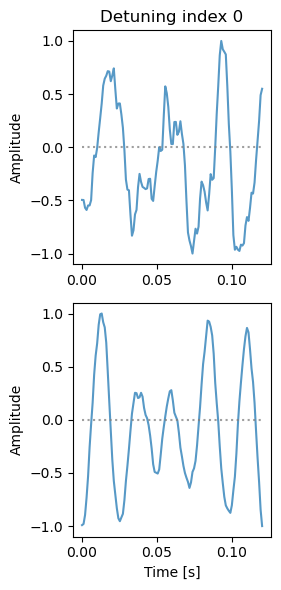

In [2]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/baselines/tesla_train_trans'
timeseries_ndim       = 1
timeseries_nsample    = 120
timestep              = 0.001

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=2)


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     7000                120        1
   valid     2000                120        1
    test     1000                120        1



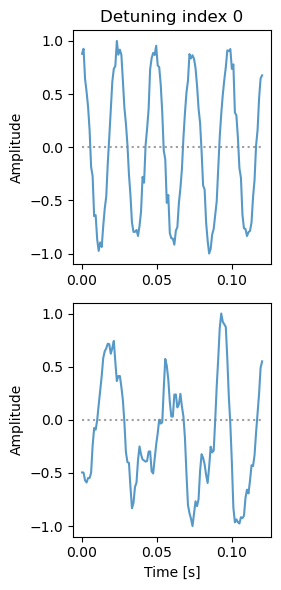

In [3]:
# --!------------------------------------------------------!
# --! display transient dataset

datadir               = '../../data/baselines/tesla_train_mixed'
timeseries_ndim       = 1
timeseries_nsample    = 120
timestep              = 0.001

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=2)

In [4]:
# --! load a trained stationary model --!

model = torch.load('../../models/baselines/tesla_kind_stat.pt', weights_only=False)
model.train()

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/tesla_train_stat',
    'transdatadir'          : '../../data/baselines/tesla_train_trans',
    'mixdatadir'            : '../../data/baselines/tesla_train_mixed',
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

t_start = time.time()

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

t_end     = time.time()
t_elapsed = t_end - t_start
print(f'inf >> training time elapsed: {t_elapsed:.1f} seconds')

inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering transient mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering transient variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training fil

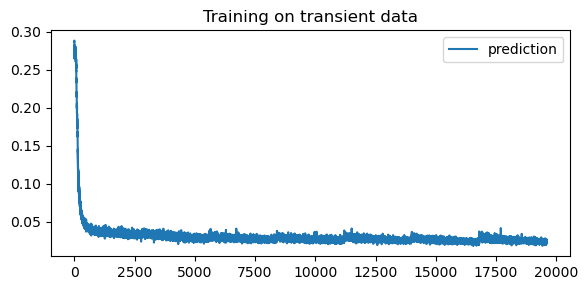

In [5]:
# --! plot training statistics --!

with torch.no_grad():
    loss_trans = loss[1]

    plt.figure(figsize=(6, 3))

    plt.title('Training on transient data')
    plt.plot(loss_trans[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# --! switch the trained model to evaluation mode --!

model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (3): Sequential(
          (0): Linear(in_features=128, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=8, out_features=8, bias=False)
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Seque

In [7]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 2000
mse                = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> evaluation results:

         mse      index      value
 -----------   --------   --------
  best blend        321      0.012
 worst blend        547      0.813
   avg blend         na      0.176
                                  
   best stat        640      0.091
  worst stat       1060      0.254
    avg stat         na      0.591
                                  
  best trans        322      0.016
 worst trans        738      0.756
   avg trans         na      0.173



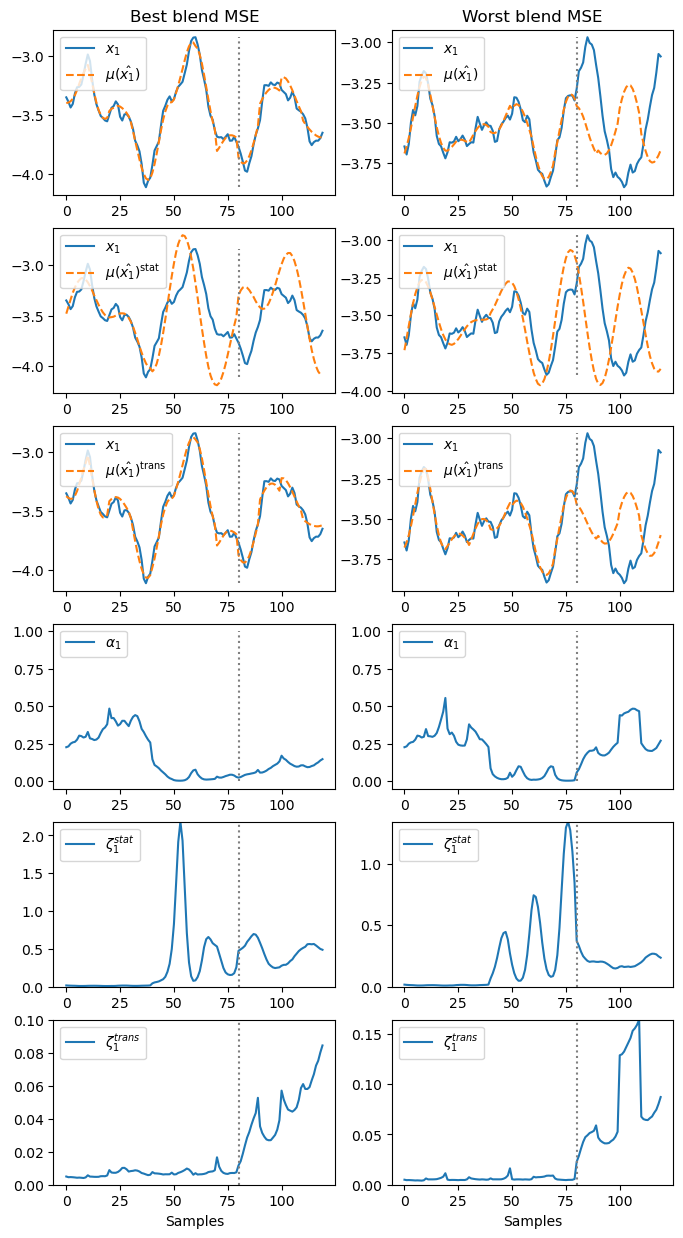

In [8]:
utils_plot.plot_mse_extreme(model, mse, datadir, timeseries_nsample)